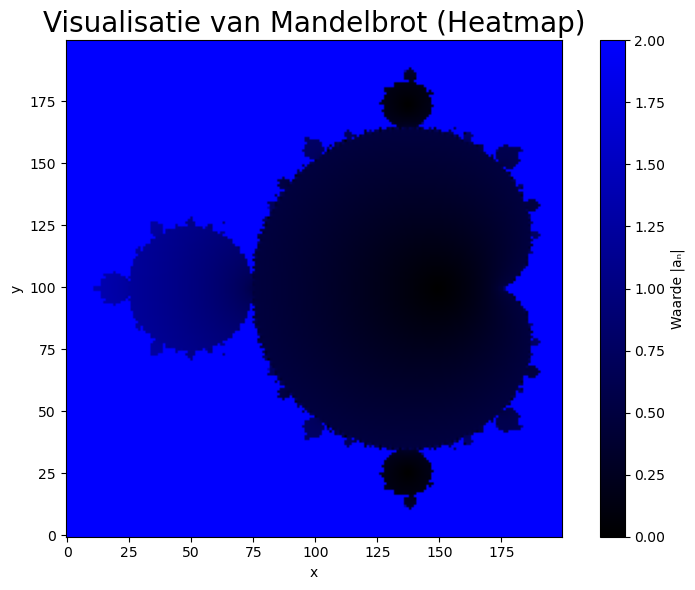

In [ ]:
# Samengevoegd2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
 
# belangrijke waardes die niet thuishoren in de functie

x_min = -1.5 # minimale x
x_max = 0.5 # maximale x
y_min = -1  # minimale y
y_max = 1 # maximale y

# figuur tekenen met functie draw_mandel
def draw_mandel(width):

    # Stap 1.1 belangrijke lists aanmaken
    c = [] # maakt een lijst aan voor alle c's die we nodig hebben
    x = [] # maakt een lijst voor elke x waarde
    y = [] # maakt een lijst voor elke y waarde
    sequence_mandelbrot = []

    # Stap 1.2 belangrijke x en y's berekenen en elke c uitbereken
    x.extend(np.linspace(x_min, x_max, width)) # Maakt alle benodige x   
    y.extend(np.linspace(y_min, y_max, width)) # Maakt alle benodige y
    
    for x_value in x: # Pakt alle x van de x lijst
        for y_value in y: # Pakt alle y van de y lijst
            c.append(x_value + y_value * 1j) # Rekened de x + y*i uit en voegt deze toe aan een list

    # Stap 1.3 paar parameters nog bepalen voor dat we verder gaan met rekenen            
    n = width # Aantal gegenereerde formulewaarden op interval [x_min, x_max ]
    a0 = 0 # Begin getal
    index = 0 # Index itereren over lijst met functiewaarden
    max_stappen = width+1  # briljant bedacht      


    # Stap 2: sequence genereren van n getallen in range x = [-1.5, 0.5]
    for c_waarde in c:
        an_oud = 0  # Op 0 beginnen voor elk nieuw complex getal
        n = 0
        # oude waarde checken
        while abs(an_oud) <= 2 and n < max_stappen:
            an_nieuw = an_oud**2 + c_waarde  # Nieuwe waarde berekenen
            an_oud = an_nieuw                # Update an_oud voor volgende stap
            n += 1 # n = n+1
        sequence_mandelbrot.append(abs(an_oud)) 

    grid = np.array(sequence_mandelbrot).reshape(width,width)# om een figuur aan te maken
    grid_gedraaid = np.rot90(grid) # figuur met 90 graden naar links draaien
    plt.figure(figsize =(8,6)) # bepaalt de grote van de afbeelding
    plt.title('Visualisatie van Mandelbrot (Heatmap)',fontsize=20)  # Geeft een title
    kleuren = LinearSegmentedColormap.from_list( # Geeft de kleuren van de heatmap aan
        "zwart_blauw",
        ["black", "blue"])

    plt.imshow( # functie uit de matplotlib toolbox
            grid_gedraaid, # alle waardes 
            cmap=kleuren, # kleur overgang
            vmin=0, # onderste scheidingsgebeid van de kleuren
            vmax=2, # bovenste scheidingsgebeid van de kleuren
            origin='lower' # zet de y-as goed
        )

    plt.colorbar(label="Waarde |aₙ|") # Geeft een label aan de heatmap bar
    plt.xlabel('x') # geeft een x een title
    plt.ylabel('y') # geeft een y een title

    plt.tight_layout()  # doet een tight layout
    plt.show() # laat de plot zien

draw_mandel(200)